In [1]:
import json
with open("golgg_games.json") as f:
    games = json.load(f)

print(len(games))
games = list({g["game_id"]:g for g in games}.values())
print(len(games))
games = sorted(games, key=lambda x: (x["date"], x["match_id"], x["game_id"]))


62530
62456


In [78]:
matches = {}
for g in games:
    mid = g["match_id"]
    if mid not in matches:
        matches[mid] = {
            "match_id": mid,
            "date": g["date"],
            "tournament": g["tournament"],
            "name_1": g["t1_name"],
            "name_2": g["t2_name"],
            "tid_1": g["t1_id"],
            "tid_2": g["t2_id"],
            "score_1": 0,
            "score_2": 0,
            "players_1": [p["player_id"] for p in g["t1_players"].values()],
            "players_2": [p["player_id"] for p in g["t2_players"].values()],
            "games": []
        }
    
    t1_win = g["t1_win"]
    if g["t1_id"] != matches[mid]["tid_1"]:
        t1_win = 1 - t1_win  # swap if team ids don't match
    matches[mid]["score_1"] += int(t1_win)
    matches[mid]["score_2"] += int(1 - t1_win)
    matches[mid]["t1_win"] = matches[mid]["score_1"] > matches[mid]["score_2"]
    matches[mid]["BoN"] = max(matches[mid]["score_1"], matches[mid]["score_2"]) * 2 - 1
    matches[mid]["games"].append(g)

matches = list(sorted(matches.values(), key=lambda x: (x["date"], x["match_id"])))

In [79]:
len(matches)

38827

In [2]:
import json 
with open("golgg_matches.json", 'r') as f:
    matches = json.load(f)

In [37]:
# Init ratings
from collections import defaultdict
from glicko2 import Player
from trueskill import TrueSkill
from openskill.models import PlackettLuce, ThurstoneMostellerFull

ts_model = TrueSkill(draw_probability=0.0, beta=5)
pl_model = PlackettLuce(beta=6)
tm_model = ThurstoneMostellerFull()

team_elo = defaultdict(lambda: 1500)
team_gl = defaultdict(lambda: Player())
team_ts = defaultdict(lambda: ts_model.create_rating())
team_pl = defaultdict(lambda: pl_model.rating())
team_tm = defaultdict(lambda: tm_model.rating())
player_elo = defaultdict(lambda: 1500)
player_gl = defaultdict(lambda: Player())
player_ts = defaultdict(lambda: ts_model.create_rating())
player_pl = defaultdict(lambda: pl_model.rating())
player_tm = defaultdict(lambda: tm_model.rating())
y_predicts = {
    "team_elo": [],
    "team_gl": [],
    "team_ts": [],
    "team_pl": [],
    "team_tm": [],
    "player_elo": [],
    "player_gl": [],
    "player_ts": [],
    "player_pl": [],
    "player_tm": [],
    "bon_team_elo": [],
    "bon_team_gl": [],
    "bon_team_ts": [],
    "bon_team_pl": [],
    "bon_team_tm": [],
    "bon_player_elo": [],
    "bon_player_gl": [],
    "bon_player_ts": [],
    "bon_player_pl": [],
    "bon_player_tm": [],
    "BoN": [],
    "date": [],
    "tournament": []
}

In [38]:
from math import sqrt
from statistics import mean
def elo_players_rating(players):
    return sum(player_elo[p] for p in players) / len(players)

def update_team_elo(t1, t2, score_1, score_2, k=64):
    R1 = team_elo[t1]
    R2 = team_elo[t2]
    E1 = 1 / (1 + 10 ** ((R2 - R1) / 400))
    E2 = 1 / (1 + 10 ** ((R1 - R2) / 400))
    S1 = score_1 / (score_1 + score_2)
    S2 = score_2 / (score_1 + score_2)
    team_elo[t1] += k * (S1 - E1)
    team_elo[t2] += k * (S2 - E2)

def update_player_elo(players_1, players_2, score_1, score_2, k=32):
    team_elo_1 = elo_players_rating(players_1)
    team_elo_2 = elo_players_rating(players_2)
    E1 = 1 / (1 + 10 ** ((team_elo_2 - team_elo_1) / 400))

    for player_1 in players_1:
        player_rank = player_elo[player_1]
        # Update player to team average
        ratio = team_elo_1 / player_rank if player_rank > 0 else 1.0
        player_elo[player_1] += k * (score_1 - E1)* ratio


    E2 = 1 / (1 + 10 ** ((team_elo_1 - team_elo_2) / 400))
    for player_2 in players_2:
        player_rank = player_elo[player_2]
        # Update player to team average
        ratio = team_elo_2 / player_rank if player_rank > 0 else 1.0
        player_elo[player_2] += k * (score_2 - E2) * ratio

player_last_played = {}
team_last_played = {}
from datetime import datetime, date



def apply_time_decay(player: Player, last_played_date, current_date, period_days=7):
    if last_played_date is None:
        return  # nowy gracz - już ma wysokie RD

    days = (current_date - last_played_date).days
    if days <= 0:
        return

    periods = days // period_days
    for _ in range(periods):
        player.did_not_compete()

def get_player_gl(player_id):
    player = player_gl[player_id]
    return player

def update_player_gl_rd(player_id, current_date):
    last_time_played = player_last_played.get(player_id)
    player = player_gl[player_id]
    apply_time_decay(player, last_time_played, current_date)
    player_last_played[player_id] = current_date

def update_team_gl_rd(team_id, current_date):
    last_time_played = team_last_played.get(team_id)
    player = team_gl[team_id]
    apply_time_decay(player, last_time_played, current_date)
    team_last_played[team_id] = current_date

def get_team_gl(team_id) -> Player:
    player = team_gl[team_id]
    return player

def glicko_players_rating(players: list[Player]):
    ratings = [p.rating for p in players]
    rds = [p.rd**2 for p in players]

    return mean(ratings), sqrt(mean(rds))

def update_team_gl(players_1, players_2, scores: list[int]):
    p1: Player = get_team_gl(players_1)
    p2: Player = get_team_gl(players_2)

    rating_list_1 = [p2.rating] * len(scores)
    rd_list_1 = [p2.rd] * len(scores)
    rating_list_2 = [p1.rating] * len(scores)
    rd_list_2 = [p1.rd] * len(scores)

    p1.update_player(rating_list_1, rd_list_1, outcome_list=scores)
    p2.update_player(rating_list_2, rd_list_2, outcome_list=[1 - s for s in scores])
    team_gl[players_1] = p1
    team_gl[players_2] = p2

def update_player_gl(players_1: list[str], players_2: list[str], scores: list[int]):
    p1 = [get_player_gl(p) for p in players_1]
    p2 = [get_player_gl(p) for p in players_2]

    t1_rating, t1_rd = glicko_players_rating(p1)
    t2_rating, t2_rd = glicko_players_rating(p2)
    rating_list_1 = [t2_rating] * len(scores)
    rd_list_1 = [t2_rd] * len(scores)
    rating_list_2 = [t1_rating] * len(scores)
    rd_list_2 = [t1_rd] * len(scores)

    for p, player_id in zip(p1, players_1):
        p.update_player(rating_list_1, rd_list_1, outcome_list=scores)
        player_gl[player_id] = p

    for p, player_id in zip(p2, players_2):
        p.update_player(rating_list_2, rd_list_2, outcome_list=[1 - s for s in scores])
        player_gl[player_id] = p

def update_team_ts(players_1, players_2, score_1, score_2):
    r1 = team_ts[players_1]
    r2 = team_ts[players_2]
    if score_1 > score_2:
        r1, r2 = ts_model.rate([[r1], [r2]])
    else:
        r2, r1 = ts_model.rate([[r2], [r1]])
    team_ts[players_1] = r1[0]
    team_ts[players_2] = r2[0]
    
def update_player_ts(players_1, players_2, score_1, score_2):
    r1 = [player_ts[p] for p in players_1]
    r2 = [player_ts[p] for p in players_2]
    if score_1 > score_2:
        r1, r2 = ts_model.rate([r1, r2])
    else:
        r2, r1 = ts_model.rate([r2, r1])
    for p, player_id in zip(r1, players_1):
        player_ts[player_id] = p
    for p, player_id in zip(r2, players_2):
        player_ts[player_id] = p

def update_team_pl(players_1, players_2, score_1, score_2):
    r1 = team_pl[players_1]
    r2 = team_pl[players_2]
    if score_1 > score_2:
        r1, r2 = pl_model.rate([[r1], [r2]])
    else:
        r2, r1 = pl_model.rate([[r2], [r1]])
    team_pl[players_1] = r1[0]
    team_pl[players_2] = r2[0]

def update_player_pl(players_1, players_2, score_1, score_2):
    r1 = [player_pl[p] for p in players_1]
    r2 = [player_pl[p] for p in players_2]
    if score_1 > score_2:
        r1, r2 = pl_model.rate([r1, r2])
    else:
        r2, r1 = pl_model.rate([r2, r1])
    for p, player_id in zip(r1, players_1):
        player_pl[player_id] = p
    for p, player_id in zip(r2, players_2):
        player_pl[player_id] = p

def update_team_tm(players_1, players_2, score_1, score_2):
    r1 = team_tm[players_1]
    r2 = team_tm[players_2]
    if score_1 > score_2:
        r1, r2 = tm_model.rate([[r1], [r2]])
    else:
        r2, r1 = tm_model.rate([[r2], [r1]])
    team_tm[players_1] = r1[0]
    team_tm[players_2] = r2[0]

def update_player_tm(players_1, players_2, score_1, score_2):
    r1 = [player_tm[p] for p in players_1]
    r2 = [player_tm[p] for p in players_2]
    if score_1 > score_2:
        r1, r2 = tm_model.rate([r1, r2])
    else:
        r2, r1 = tm_model.rate([r2, r1])
    for p, player_id in zip(r1, players_1):
        player_tm[player_id] = p
    for p, player_id in zip(r2, players_2):
        player_tm[player_id] = p

def update_after_game(t1, t2, players_1, players_2, score_1, score_2):
    update_team_elo(t1, t2, score_1, score_2)
    update_player_elo(players_1, players_2, score_1, score_2)
    update_team_ts(t1, t2, score_1, score_2)
    update_player_ts(players_1, players_2, score_1, score_2)
    update_team_pl(t1, t2, score_1, score_2)
    update_player_pl(players_1, players_2, score_1, score_2)
    update_team_tm(t1, t2, score_1, score_2)
    update_player_tm(players_1, players_2, score_1, score_2)

def update_after_match(t1, t2, players_1, players_2, scores):
    update_team_gl(t1, t2, scores)
    update_player_gl(players_1, players_2, scores)

def update_before_match(t1, t2, players_1, players_2, match_date):
    for p in players_1:
        update_player_gl_rd(p, current_date=match_date)
    for p in players_2:
        update_player_gl_rd(p, current_date=match_date)

    update_team_gl_rd(t1, current_date=match_date)
    update_team_gl_rd(t2, current_date=match_date)
    

In [39]:
# prediction cell
from math import comb
import math
import trueskill
def match_win_probability(p: float, bon: int) -> float:
    wins_needed = bon // 2 + 1
    probability = 0.0

    for k in range(wins_needed, bon + 1):
        probability += comb(bon, k) * (p ** k) * ((1 - p) ** (bon - k))

    return probability

print(match_win_probability(0.6, 3))  # best of 3
print(match_win_probability(0.6, 5))  # best of 5

def expected_ts_score(team_a: list[trueskill.Rating], team_b: list[trueskill.Rating]):
    mu_a = sum(r.mu for r in team_a) / len(team_a)
    mu_b = sum(r.mu for r in team_b) / len(team_b)

    # 2. Oblicz średnią wariancję (sigma^2) dla obu drużyn
    sigma2_a = sum(r.sigma ** 2 for r in team_a) / len(team_a)
    sigma2_b = sum(r.sigma ** 2 for r in team_b) / len(team_b)

    # 3. Różnica umiejętności
    delta_mu = mu_a - mu_b

    # 4. Mianownik (Niepewność)
    # Używamy 2 * beta^2 (jak w 1vs1), ponieważ operujemy na średnich.
    # To jest klucz do naprawy Log Loss.
    denom = math.sqrt(sigma2_a + sigma2_b + 2 * (ts_model.beta ** 2))

    # 5. Zwracamy prawdopodobieństwo (CDF)
    # Używamy globalnego env trueskill do obliczenia dystrybuanty
    return ts_model.cdf(delta_mu / denom)

def g(rd):
    q = math.log(10) / 400
    return 1 / math.sqrt(1 + 3 * (q ** 2) * (rd ** 2) / (math.pi ** 2))

def expected_gl_score(player_i, player_j):

    ri = player_i.rating
    rj = player_j.rating
    RDi = player_i.rd
    RDj = player_j.rd

    combined_rd = math.sqrt(RDi**2 + RDj**2)
    g_factor = g(combined_rd)

    exponent = -g_factor * (ri - rj) / 400

    E = 1 / (1 + 10 ** exponent)
    return E

def predict_match(t1, t2, players_1, players_2):
    predictions = {}
    # Team Elo
    r1 = team_elo[t1]
    r2 = team_elo[t2]
    E1 = 1 / (1 + 10 ** ((r2 - r1) / 400))
    predictions["team_elo"] = E1

    # Team Glicko
    p1 = team_gl[t1]
    p2 = team_gl[t2]
    glicko_E1 = expected_gl_score(p1, p2)
    predictions["team_gl"] = glicko_E1

    # Team TrueSkill
    r1 = team_ts[t1]
    r2 = team_ts[t2]
    ts_E1 = expected_ts_score([r1], [r2])
    predictions["team_ts"] = ts_E1

    # Team PlackettLuce
    r1 = team_pl[t1]
    r2 = team_pl[t2]
    pl_E1 = pl_model.predict_win([[r1], [r2]])[0]
    predictions["team_pl"] = pl_E1

    # Team ThurstoneMostellerFull
    r1 = team_tm[t1]
    r2 = team_tm[t2]
    tm_E1 = tm_model.predict_win([[r1], [r2]])[0]
    predictions["team_tm"] = tm_E1

    # Player Elo
    team_elo_1 = elo_players_rating(players_1)
    team_elo_2 = elo_players_rating(players_2)
    E1 = 1 / (1 + 10 ** ((team_elo_2 - team_elo_1) / 400))
    predictions["player_elo"] = E1

    # Player Glicko
    p1 = [player_gl[p] for p in players_1]
    p2 = [player_gl[p] for p in players_2]
    t1_rating, t1_rd = glicko_players_rating(p1)
    t2_rating, t2_rd = glicko_players_rating(p2)
    glicko_E1 = expected_gl_score(Player(t1_rating, t1_rd), Player(t2_rating, t2_rd))
    predictions["player_gl"] = glicko_E1

    # Player TrueSkill
    r1 = [player_ts[p] for p in players_1]
    r2 = [player_ts[p] for p in players_2]
    ts_E1 = expected_ts_score(r1, r2)
    predictions["player_ts"] = ts_E1

    # Player PlackettLuce
    r1 = [player_pl[p] for p in players_1]
    r2 = [player_pl[p] for p in players_2]
    pl_E1 = pl_model.predict_win([r1, r2])[0]
    predictions["player_pl"] = pl_E1

    # Player ThurstoneMostellerFull
    r1 = [player_tm[p] for p in players_1]
    r2 = [player_tm[p] for p in players_2]
    tm_E1 = tm_model.predict_win([r1, r2])[0]
    predictions["player_tm"] = tm_E1    
    
    return predictions


def add_bon_predictions(predictions, bon):
    for key in list(predictions.keys()):
        p = predictions[key]
        bon_p = match_win_probability(p, bon)
        predictions[f"bon_{key}"] = bon_p

def add_to_y_predicts(y_predicts, predictions, bon, date, tournament):
    for key, value in predictions.items():
        y_predicts[key].append(value)

    y_predicts["BoN"].append(bon)
    y_predicts["date"].append(date)
    y_predicts["tournament"].append(tournament) 
    predictions["BoN"] = bon
    predictions["date"] = date
    predictions["tournament"] = tournament


0.648
0.68256


In [40]:
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm import tqdm
from dateutil.relativedelta import relativedelta
from datetime import date
import pandas as pd
y_trues = []
interval_y_true = []
INTERVAL_YEARS = 2
interval_predictions = []
end_date = date.fromisoformat("2014-01-01")
aucs = []
for match in tqdm(matches, desc="Processing matches"):
    mid = match["match_id"]
    t1 = match["tid_1"]
    t2 = match["tid_2"]
    match_date = date.fromisoformat(match["date"])
    players_1 = match["players_1"]
    players_2 = match["players_2"]
    scores = []
    update_before_match(t1, t2, players_1, players_2, match_date)
    predictions = predict_match(t1, t2, players_1, players_2)
    add_bon_predictions(predictions, match["BoN"])

    interval_predictions.append({
        "date": match_date,
        **predictions
    })
    interval_y_true.append({"date": match_date, "y_true": int(match["t1_win"])})
    add_to_y_predicts(y_predicts, predictions, match["BoN"], match_date, tournament=match["tournament"] )
    y_trues.append(int(match["t1_win"]))

    if match_date >= end_date:
        end_date += relativedelta(months=2)
        df = pd.DataFrame(interval_predictions)
        X = df["player_ts"]
        y = pd.DataFrame(interval_y_true)["y_true"]
        auc = roc_auc_score(y, X)
        acc = accuracy_score(y, [1 if p >= 0.5 else 0 for p in X])
        aucs.append({
            "date": end_date, "auc": auc, "accuracy": acc, "n_matches": len(y)})
        back_date = end_date 
        interval_predictions = [pred for pred in interval_predictions if pred["date"] >= end_date - relativedelta(months=4)]
        interval_y_true = [yt for yt in interval_y_true if yt["date"] >= end_date - relativedelta(months=4)]
        if auc <= 0.7:
            print(f"Warning: AUC dropped below 0.7 ({auc}) for interval {end_date - relativedelta(months=4)} - {end_date}")

    for game in match["games"]:
        score_1 = int(game["t1_win"])
        score_2 = 1 - score_1
        if game["t1_id"] != match["tid_1"]:
            score_1, score_2 = score_2, score_1  # swap if team ids don't match

        scores.append(score_1)
        update_after_game(t1, t2, players_1, players_2, score_1, score_2)

    update_after_match(t1, t2, players_1, players_2, scores)

Processing matches:   0%|          | 0/38827 [00:00<?, ?it/s]

Processing matches:   1%|          | 363/38827 [00:00<00:42, 900.82it/s]

Processing matches:   1%|▏         | 554/38827 [00:00<00:45, 844.27it/s]

Processing matches:   2%|▏         | 640/38827 [00:00<00:51, 747.43it/s]

Processing matches:   2%|▏         | 949/38827 [00:01<00:50, 747.32it/s]

...

Processing matches:  55%|█████▌    | 21466/38827 [00:32<00:21, 823.39it/s]

Processing matches:  58%|█████▊    | 22399/38827 [00:33<00:27, 594.30it/s]

Processing matches:  69%|██████▉   | 26864/38827 [00:39<00:15, 769.31it/s]

Processing matches:  72%|███████▏  | 27845/38827 [00:41<00:19, 565.34it/s]

Processing matches: 100%|██████████| 38827/38827 [01:00<00:00, 640.94it/s]


In [41]:
# with open("golgg_y_predicts.json", 'w') as f:
#     # Fix dates to isoformat
#     for i in range(len(y_predicts["date"])):
#         y_predicts["date"][i] = y_predicts["date"][i].isoformat()
#     json.dump(y_predicts, f, indent=2)

df = pd.DataFrame(y_predicts)
df["y_true"] = y_trues
df.to_csv("golgg_y_predicts.csv", index=False)

In [42]:
df = pd.read_csv("golgg_y_predicts.csv")
df["date"] = pd.to_datetime(df["date"]).dt.date

8576
AUC Scores:
Player Glicko: 0.763
Player Elo: 0.747
Player PlackettLuce: 0.742
Player TrueSkill: 0.736
Player ThurstoneMostellerFull: 0.719


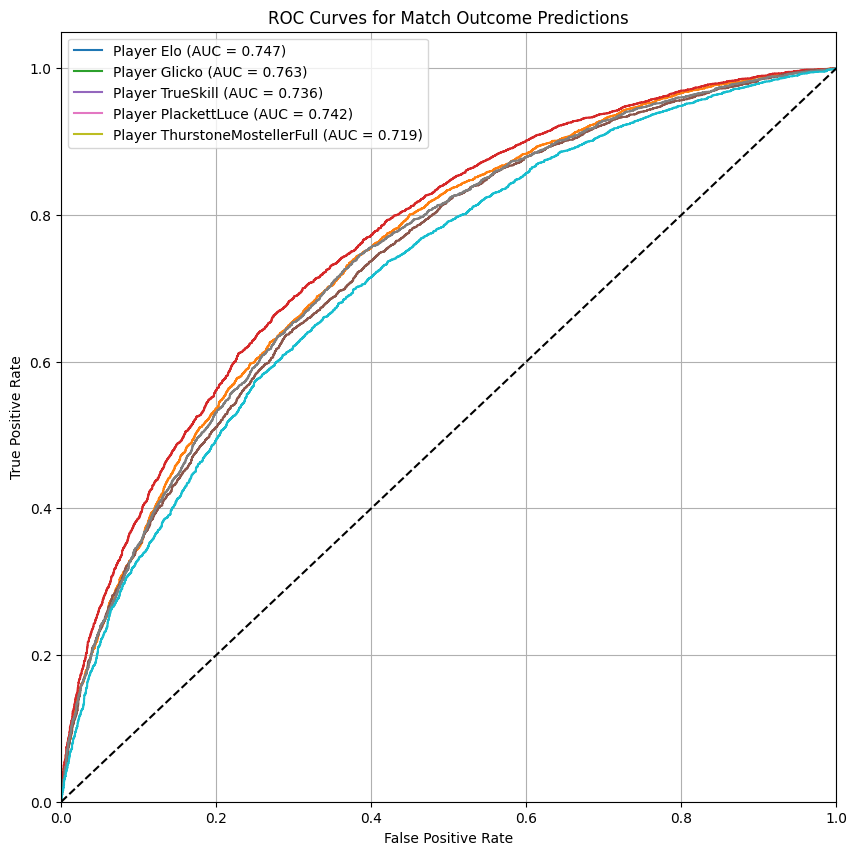

In [44]:
import pandas as pd
interval_df = df[(df["date"] >= date.fromisoformat("2024-01-01"))]
X = interval_df.drop(columns=["y_true"])
y = interval_df["y_true"]
print(len(y))

metrics = {
    # "Team Elo": "team_elo",
    # "Team Glicko": "team_gl",
    # "Team TrueSkill": "team_ts",
    # "Team PlackettLuce": "team_pl",
    # "Team ThurstoneMostellerFull": "team_tm",
    "Player Elo": "player_elo",
    "Player Glicko": "player_gl",
    "Player TrueSkill": "player_ts",
    "Player PlackettLuce": "player_pl",
    "Player ThurstoneMostellerFull": "player_tm",
#     "Bon Team Elo": "bon_team_elo",
#     "Bon Team Glicko": "bon_team_gl",
#     "Bon Team TrueSkill": "bon_team_ts",
#     "Bon Team PlackettLuce": "bon_team_pl",
#     "Bon Team ThurstoneMostellerFull": "bon_team_tm",
#     "Bon Player Elo": "bon_player_elo",
#     "Bon Player Glicko": "bon_player_gl",
#     "Bon Player TrueSkill": "bon_player_ts",
#     "Bon Player PlackettLuce": "bon_player_pl",
#     "Bon Player ThurstoneMostellerFull": "bon_player_tm"
}


# Plot ROC
from sklearn.metrics import roc_auc_score, roc_curve, roc_curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
aucs = {}
for name, col in metrics.items():
    auc = roc_auc_score(y, X[col])
    aucs[name] = auc
    plt.plot([], [], label=f"{name} (AUC = {auc:.3f})")
    fpr, tpr, _ = roc_curve(y, X[col])
    plt.plot(fpr, tpr)
    
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Match Outcome Predictions')
plt.legend()

aucs = dict(sorted(aucs.items(), key=lambda item: item[1], reverse=True))
print("AUC Scores:")
for name, auc in aucs.items():
    print(f"{name}: {auc:.3f}")


# plt.legend(loc="lower right")
# plt.show()

Player Elo Mean: 0.51, Std: 0.17
Team Elo Mean: 0.51, Std: 0.20


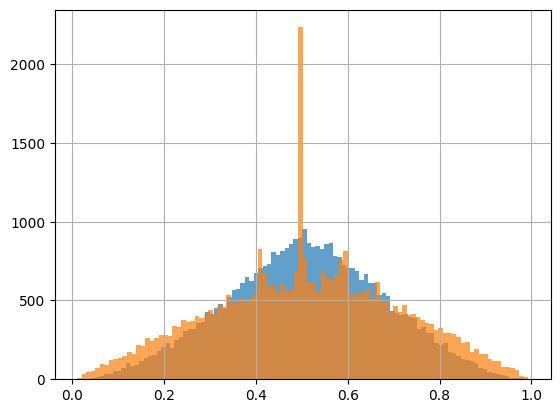

In [45]:
df["player_elo"].hist(bins=100, alpha=0.7)
mean, std = df["player_elo"].mean(), df["player_elo"].std()
print(f"Player Elo Mean: {mean:.2f}, Std: {std:.2f}")

df["team_elo"].hist(bins=100, alpha=0.7)
mean, std = df["team_elo"].mean(), df["team_elo"].std()
print(f"Team Elo Mean: {mean:.2f}, Std: {std:.2f}")



<Axes: >

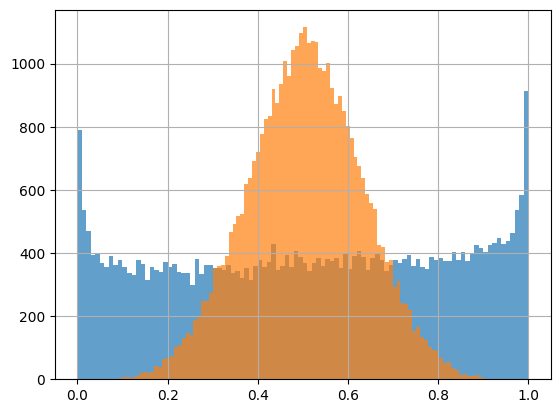

In [23]:
# df["player_elo"].hist(bins=100, alpha=0.7)
# df["player_gl"].hist(bins=100, alpha=0.7)
# df.head()
df["player_pl"].hist(bins=100, alpha=0.7)
df["player_ts"].hist(bins=100, alpha=0.7)
# plt.legend(["Elo", "Glicko", "PlackettLuce", "TrueSkill"])

In [51]:
from sklearn.metrics import brier_score_loss


# metrics = {
#     "Player Elo": "player_elo",
#     "Player Glicko": "player_gl",
#     "Player TrueSkill": "player_ts",
#     "Player PlackettLuce": "player_pl",
# }
# start_date = date.fromisoformat("2024-01-01")
# idf = df[(df["date"] >= start_date)]
# print(f"Overall Metrics (from {start_date}):")
# print(f"Number of matches: {len(idf)}")
# for name, col in metrics.items():
#     mean = df[col].mean()
#     std = df[col].std()
#     print(f"{name} - Mean: {mean:.4f}, Std: {std:.4f}")
#     auc = roc_auc_score(idf["y_true"], idf[col])
#     print(f"{name} - AUC: {auc:.4f}")
#     logloss = - (idf["y_true"] * idf[col].apply(lambda p: math.log(p + 1e-15)) + (1 - idf["y_true"]) * idf[col].apply(lambda p: math.log(1 - p + 1e-15))).mean()
#     print(f"{name} - Log Loss: {logloss:.4f}")
#     brier = brier_score_loss(idf["y_true"], idf[col])
#     print(f"{name} - Brier Score: {brier:.4f}")
#     for bon in [1, 3, 5]:
#         print(f"Metrics for Bon {bon}:")
#         bon_idf = idf[idf["BoN"] == bon]
#         print(f"  Number of matches: {len(bon_idf)}")
#         bon_auc = roc_auc_score(bon_idf["y_true"], bon_idf[f"bon_{col}"])
#         print(f"  Bon {bon} AUC: {bon_auc:.4f}")
#         logloss = - (bon_idf["y_true"] * bon_idf[col].apply(lambda p: math.log(p + 1e-15)) + (1 - bon_idf["y_true"]) * bon_idf[col].apply(lambda p: math.log(1 - p + 1e-15))).mean()
#         print(f"  Bon {bon} Log Loss: {logloss:.4f}")
#         brier = brier_score_loss(bon_idf["y_true"], bon_idf[f"bon_{col}"])
#         print(f"  Bon {bon} Brier Score: {brier:.4f}")
        
        
### Make table of metrics per score metric

metrics = {
    "Player Elo": "player_elo",
    "Player Glicko": "player_gl",
    "Player TrueSkill": "player_ts",
    "Player PlackettLuce": "player_pl",
}
start_date = date.fromisoformat("2024-01-01")
idf = df[(df["date"] >= start_date)]
print(f"Overall Metrics (from {start_date}):")
print(f"Number of matches: {len(idf)}")
import pandas as pd
results = []
for name, col in metrics.items():
    for bon in [1, 3, 5]:
        bon_idf = idf[idf["BoN"] == bon]
        if len(bon_idf) == 0:
            continue
        bon_auc = roc_auc_score(bon_idf["y_true"], bon_idf[f"bon_{col}"])
        logloss = - (bon_idf["y_true"] * bon_idf[col].apply(lambda p: math.log(p + 1e-15)) + (1 - bon_idf["y_true"]) * bon_idf[col].apply(lambda p: math.log(1 - p + 1e-15))).mean()
        brier = brier_score_loss(bon_idf["y_true"], bon_idf[f"bon_{col}"])
        results.append({
            "Metric": name,
            "BoN": bon,
            "AUC": bon_auc,
            "Log Loss": logloss,
            "Brier Score": brier,
            "Number of Matches": len(bon_idf)
        })    
        
results_df = pd.DataFrame(results)
# Display pivot table
# change pandas max width 
pd.set_option('display.max_columns', None)
print(results_df.pivot(index="Metric", columns="BoN", values=["AUC", "Log Loss", "Brier Score", "Number of Matches"]))


Overall Metrics (from 2024-01-01):
Number of matches: 8576
                          AUC                      Log Loss            \
BoN                         1         3         5         1         3   
Metric                                                                  
Player Elo           0.723353  0.784893  0.731224  0.613104  0.563247   
Player Glicko        0.744237  0.799218  0.738749  0.596174  0.556278   
Player PlackettLuce  0.723305  0.778902  0.710987  0.701588  0.609971   
Player TrueSkill     0.717231  0.773421  0.706106  0.625067  0.601115   

                              Brier Score                      \
BoN                         5           1         3         5   
Metric                                                          
Player Elo           0.610789    0.212391  0.188802  0.207216   
Player Glicko        0.610127    0.205177  0.182688  0.204014   
Player PlackettLuce  0.622501    0.226826  0.211404  0.234581   
Player TrueSkill     0.642787    0.2175

In [25]:
p1 = [pl_model.rating() for _ in range(5)]

In [26]:
p2 = [pl_model.rating(27, sigma=20) for _ in range(5)]

In [27]:
pl_model.predict_win([p1, p2])

[0.4194457519547652, 0.5805542480452348]

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Zakładam, że Twój dataframe nazywa się 'df'
# 1. Sortowanie po dacie (Kluczowe!)
df = df.sort_values('date').reset_index(drop=True)

# 2. Wybór cech (X)
# Używamy wersji 'bon_*', bo one już zawierają info o formacie serii (Bo1/Bo3/Bo5)
# Dodajemy 'BoN' jako cechę - metamodel może nauczyć się ufać innym modelom w Bo1 a innym w Bo5
features = [
    "player_elo",
    "player_gl",
    "player_ts",
    "player_pl",
    "team_elo",
    "team_gl",
    "team_ts",
    "team_pl",
    'BoN' 
]

target = 'y_true'

def prepare_features(df):
    df = df.dropna(subset=features + [target])
    X = df[features].copy()
    y = df[target].copy()
    return X, y

# Usuwamy wiersze z brakującymi danymi (jeśli są)
X, y = prepare_features(df)
df_clean = pd.concat([X, y], axis=1)

# 3. Podział na Train / Test (Time Series Split)
# Np. pierwsze 80% to trening, ostatnie 20% to test
# train_size = int(len(df_clean) * 0.8)
# X_train = prepare_features(df_clean.iloc[:train_size])
# y_train = df_clean[target].iloc[:train_size]

# X_test = df_clean[features].iloc[train_size:]
# y_test = df_clean[target].iloc[train_size:]

tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(df_clean))
train_index, test_index = splits[-1]
X_train, y_train = prepare_features(df_clean.iloc[train_index])
X_test, y_test = prepare_features(df_clean.iloc[test_index])
train_size = len(X_train)
print(f"Trening: {len(X_train)} meczów | Test: {len(X_test)} meczów")

Trening: 32356 meczów | Test: 6471 meczów


In [ ]:
# Inicjalizacja Metamodelu
# fit_intercept=True pozwala modelowi skorygować ogólny bias (np. jeśli Blue side wygrywa częściej)
meta_model = LogisticRegression(fit_intercept=True, solver='lbfgs', C=1.0)

# Trenowanie
meta_model.fit(X_train, y_train)

# Predykcja na zbiorze testowym
# predict_proba zwraca [szansa_przegranej, szansa_wygranej], bierzemy [:, 1]
meta_predictions = meta_model.predict_proba(X_test)[:, 1]

# Przypisanie wyników do DataFrame (dla wygody analizy)
df_test_results = X_test.copy()
df_test_results['meta_prob'] = meta_predictions

ValueError: Length of values (6471) does not match length of index (7766)

In [31]:
def evaluate_model(y_true, y_pred, model_name):
    ll = log_loss(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    brier = brier_score_loss(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Log Loss:    {ll:.5f}") # Im mniej tym lepiej
    print(f"AUC:         {auc:.5f}") # Im więcej tym lepiej
    print(f"Brier Score: {brier:.5f}")
    print("")

print("=== WYNIKI NA ZBIORZE TESTOWYM ===\n")

# 1. Sprawdzamy najlepszy pojedynczy model (np. Glicko Player)
evaluate_model(y_test, X_test['player_gl'], "Single Best (Glicko Player)")

# 2. Sprawdzamy Metamodel
evaluate_model(y_test, meta_predictions, "Stacking Ensemble (Meta)")

# Analiza Wg Formatów (Bo1, Bo3, Bo5)
for bon in [1, 3, 5]:
    mask = df_test_results['BoN'] == bon
    if mask.sum() > 0:
        print(f"--- Format Bo{bon} ({mask.sum()} mecze) ---")
        ll_meta = log_loss(y_test[mask], meta_predictions[mask])
        print(f"Meta Log Loss: {ll_meta:.5f}")
        auc_meta = roc_auc_score(y_test[mask], meta_predictions[mask])
        print(f"Meta AUC:      {auc_meta:.5f}\n")

=== WYNIKI NA ZBIORZE TESTOWYM ===

--- Single Best (Glicko Player) ---
Log Loss:    0.58232
AUC:         0.76499
Brier Score: 0.19891

--- Stacking Ensemble (Meta) ---
Log Loss:    0.57825
AUC:         0.76309
Brier Score: 0.19729

--- Format Bo1 (3920 mecze) ---
Meta Log Loss: 0.59092
Meta AUC:      0.74768

--- Format Bo3 (2800 mecze) ---
Meta Log Loss: 0.55176
Meta AUC:      0.79429

--- Format Bo5 (1044 mecze) ---
Meta Log Loss: 0.60088
Meta AUC:      0.73975



In [32]:
# Pobranie wag (współczynników) z regresji logistycznej
coeffs = pd.DataFrame({
    'Feature': features,
    'Weight': meta_model.coef_[0]
}).sort_values(by='Weight', ascending=False)

print("\n=== WAŻNOŚĆ MODELI (WAGI) ===")
print(coeffs)


=== WAŻNOŚĆ MODELI (WAGI) ===
      Feature    Weight
1   player_gl  3.324776
0  player_elo  2.192907
6     team_ts  0.938077
4    team_elo  0.702001
2   player_ts  0.224386
8         BoN  0.019983
5     team_gl -0.279119
3   player_pl -0.531725
7     team_pl -0.853433


In [35]:
from xgboost import XGBClassifier

# XGBoost jako meta-learner
# max_depth=2 lub 3 - chcemy płytkie drzewa, żeby nie przeuczyć (overfitting)
# n_estimators=100 - standard
meta_model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=2, 
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss'
)

meta_model_xgb.fit(X_train, y_train)
meta_predictions_xgb = meta_model_xgb.predict_proba(X_test)[:, 1]

evaluate_model(y_test, meta_predictions_xgb, "XGBoost Stacking")
for bon in [1, 3, 5]:
    mask = df_test_results['BoN'] == bon
    if mask.sum() > 0:
        print(f"--- Format Bo{bon} ({mask.sum()} mecze) ---")
        ll_meta = log_loss(y_test[mask], meta_predictions_xgb[mask])
        print(f"XGBoost Meta Log Loss: {ll_meta:.5f}")
        auc_meta = roc_auc_score(y_test[mask], meta_predictions_xgb[mask])
        print(f"XGBoost Meta AUC:      {auc_meta:.5f}\n")

--- XGBoost Stacking ---
Log Loss:    0.57833
AUC:         0.76452
Brier Score: 0.19719

--- Format Bo1 (3920 mecze) ---
XGBoost Meta Log Loss: 0.59154
XGBoost Meta AUC:      0.74858

--- Format Bo3 (2800 mecze) ---
XGBoost Meta Log Loss: 0.55162
XGBoost Meta AUC:      0.79447

--- Format Bo5 (1044 mecze) ---
XGBoost Meta Log Loss: 0.59944
XGBoost Meta AUC:      0.74209



d:\Melzak\dev\embedded-rift\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:08:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [36]:
# save model 
import pickle
with open("meta_model_xgb.pkl", 'wb') as f:
    pickle.dump(meta_model_xgb, f)

In [ ]:
# open model
with open("meta_model_xgb.pkl", 'rb') as f:
    loaded_model = pickle.load(f)
    
